# Data Understanding — Leuven ↔ Brussels Commuter Delays (Checkpoint)

**Business goal:** warn Leuven↔Brussels commuters that their train is going to be delayed, roughly one hour ahead of time.

**Scope:** the Leuven↔Brussels corridor only — the IC line via Brussels-Central, and the S-line via Brussels-Schuman. Corridor stations: Leuven, Brussels-North, Brussels-Central, Brussels-South, Brussels-Schuman, Kortenberg.

**The dataset.** ~890k rows of real per-stop punctuality history (Jan–Jul 2026), sourced from Infrabel's official punctuality archive, covering every train touching our six-station corridor across seven months — enough to see delay propagation, seasonal patterns, and rush-hour vs. off-peak behavior. This notebook is the full reference solution — it parses, joins and cleans the historical data, answers every guiding question with real code and output, and ends by saving a per-stop-event checkpoint for the feature engineering stage.

In [1]:
import os

# make "../../data/..." paths resolve whether Jupyter was launched from the repo root or from notebooks/
if not os.path.isdir("../../data") and os.path.isdir("data"):
    os.chdir("notebooks/assignment_notebooks")

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

INFRABEL_PATH = "../../data/raw/infrabel_historical_2026.csv"
WEATHER_PATH = "../../data/raw/weather_historical.csv"
STOPS_PATH = "../../data/raw/stops.txt"  # static station reference only -- IDs don't match the punctuality data, don't join by ID
CHECKPOINT_PATH = "../../data/checkpoints/clean_leuven_corridor.parquet"

CORRIDOR_STATIONS = ["LEUVEN", "BRUSSEL-NOORD", "BRUSSEL-CENTRAAL", "BRUSSEL-ZUID", "BRUSSEL-SCHUMAN", "KORTENBERG"]
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

A quick look at each raw file before doing anything to it.

In [3]:
pd.set_option("display.max_columns", None)  # show all 23 columns instead of truncating with "..."
pd.read_csv(INFRABEL_PATH).head()

,DATDEP,CIRC_TYP,TRAIN_NO,RELATION,TRAIN_SERV,OP1_COD,THOP1_COD,PTCAR_NO,PTCAR_LG_NM_NL,LINE_NO_DEP,REAL_DATE_ARR,REAL_TIME_ARR,REAL_DATE_DEP,REAL_TIME_DEP,PLANNED_DATE_ARR,PLANNED_TIME_ARR,PLANNED_TIME_DEP,PLANNED_DATE_DEP,DELAY_ARR,DELAY_DEP,RELATION_DIRECTION,LINE_NO_ARR,source_month
0,01JAN2026,1,11,ICE,SNCB/NMBS,NaN,NaN,220,BRUSSEL-ZUID,0/1,NaN,NaN,01JAN2026,6:22:58,NaN,NaN,6:23:00,01JAN2026,NaN,-1.0,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,NaN,202601
1,01JAN2026,1,11,ICE,SNCB/NMBS,P,P,215,BRUSSEL-CENTRAAL,0/1,01JAN2026,6:25:54,01JAN2026,6:25:54,01JAN2026,6:26:00,6:26:00,01JAN2026,-6.0,-6.0,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,0/1,202601
2,01JAN2026,1,11,ICE,SNCB/NMBS,=,=,221,BRUSSEL-NOORD,36N,01JAN2026,6:29:01,01JAN2026,6:31:12,01JAN2026,6:29:00,6:31:00,01JAN2026,2.0,12.0,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,0/1,202601
3,01JAN2026,1,11,ICE,SNCB/NMBS,D,D,648,KORTENBERG,36N,01JAN2026,6:38:15,01JAN2026,6:38:15,01JAN2026,6:39:00,6:39:00,01JAN2026,-45.0,-45.0,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,36N,202601
4,01JAN2026,1,11,ICE,SNCB/NMBS,P,P,715,LEUVEN,2,01JAN2026,6:43:04,01JAN2026,6:43:04,01JAN2026,6:45:00,6:45:00,01JAN2026,-116.0,-116.0,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,36N,202601


**What each column means** (official names/descriptions from [Infrabel's open data portal](https://opendata.infrabel.be/explore/dataset/stiptheid-gegevens-maandelijksebestanden/information/), the source of this file):

| Column | Meaning |
|---|---|
| `DATDEP` | Date of departure for the whole trip -> `service_date` |
| `TRAIN_NO` | Train number. Recurs daily, and occasionally reused for a *different* circulation later the same day -- not a unique key on its own (more on this in Data Quality below) |
| `RELATION` | Service type, e.g. `ICE`, `IC`, `S` -> source of `train_type` later |
| `RELATION_DIRECTION` | Full route, e.g. "ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF" |
| `TRAIN_SERV` | Operator -- always `SNCB/NMBS` here, not discriminating |
| `PTCAR_NO` | Numeric code for the stopping point (station) |
| `PTCAR_LG_NM_NL` | Stopping point's Dutch name, e.g. `BRUSSEL-ZUID` -> mapped to our English station names |
| `LINE_NO_DEP` / `LINE_NO_ARR` | Rail line number when departing / arriving this stop -- infrastructure detail, not used as a feature |
| `REAL_DATE_ARR` / `REAL_TIME_ARR` | Actual arrival date/time -> `real_arrival`. Empty at a run's first stop (nothing to arrive from) |
| `REAL_DATE_DEP` / `REAL_TIME_DEP` | Actual departure date/time -> `real_departure`. Empty at a run's last stop |
| `PLANNED_DATE_ARR` / `PLANNED_TIME_ARR` | Scheduled arrival -> `planned_arrival`, same structural emptiness pattern |
| `PLANNED_DATE_DEP` / `PLANNED_TIME_DEP` | Scheduled departure -> `planned_departure` |
| `DELAY_ARR` | Arrival delay in **seconds** (real - planned, can be negative) -> `delay_arr_s` / `delay_arr_min` |
| `DELAY_DEP` | Departure delay in seconds -> `delay_dep_s` / `delay_dep_min` |
| `source_month` | Not from Infrabel -- added when we fetched each month's file. What the time-based train/val/test split partitions on later |

**Not documented anywhere, including by Infrabel themselves:** `OP1_COD`, `THOP1_COD` (single-character codes: `=`, `P`, `D`, `(`, `)`, `>` -- pattern-consistent with stop-type markers, but unconfirmed) and `CIRC_TYP` (constant `1` throughout this corridor slice, unused). Carried through the pipeline as-is rather than guessed at further.

In [4]:
pd.read_csv(WEATHER_PATH).head()

,time,location,temperature_2m,precipitation,rain,wind_speed_10m,wind_gusts_10m,weather_code
0,2026-01-01T00:00,Brussels,0.6,0.0,0.0,16.3,32.4,0
1,2026-01-01T01:00,Brussels,0.2,0.0,0.0,16.5,32.8,1
2,2026-01-01T02:00,Brussels,0.3,0.0,0.0,16.2,33.8,1
3,2026-01-01T03:00,Brussels,0.4,0.0,0.0,17.3,35.3,1
4,2026-01-01T04:00,Brussels,0.2,0.0,0.0,17.8,36.7,0


**What each column means** ([Open-Meteo historical archive API](https://open-meteo.com/en/docs/historical-weather-api), no key required):

| Column | Meaning |
|---|---|
| `time` | Hourly timestamp, local time (Europe/Brussels) |
| `location` | `Brussels` or `Leuven` -- matches `weather_location` on the delay side |
| `temperature_2m` | Air temperature at 2m above ground, °C |
| `precipitation` | Total precipitation (rain + showers + snow) in the preceding hour, mm |
| `rain` | Liquid precipitation only (excludes snow) in the preceding hour, mm |
| `wind_speed_10m` | Wind speed at 10m above ground, km/h |
| `wind_gusts_10m` | Wind gusts at 10m above ground, km/h |
| `weather_code` | Numeric WMO weather code (0 = clear, higher = increasingly severe: fog, drizzle, rain, snow, storms) -- mapped to the readable `weather_bucket` categories below |

## Setting Up: Parsing & Cleaning

The raw file is already filtered to our 6 corridor stations, one row per train's stop at a station (arrival + departure together). Dates are `01JAN2026` style, times are `H:MM:SS` with no leading zero. We turn those into real datetimes and numbers, and attach a clean station name.

In [5]:
raw = pd.read_csv(INFRABEL_PATH, dtype=str)
print(raw.shape)
raw.head()

(890283, 23)


,DATDEP,CIRC_TYP,TRAIN_NO,RELATION,TRAIN_SERV,OP1_COD,THOP1_COD,PTCAR_NO,PTCAR_LG_NM_NL,LINE_NO_DEP,REAL_DATE_ARR,REAL_TIME_ARR,REAL_DATE_DEP,REAL_TIME_DEP,PLANNED_DATE_ARR,PLANNED_TIME_ARR,PLANNED_TIME_DEP,PLANNED_DATE_DEP,DELAY_ARR,DELAY_DEP,RELATION_DIRECTION,LINE_NO_ARR,source_month
0,01JAN2026,1,11,ICE,SNCB/NMBS,NaN,NaN,220,BRUSSEL-ZUID,0/1,NaN,NaN,01JAN2026,6:22:58,NaN,NaN,6:23:00,01JAN2026,NaN,-1,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,NaN,202601
1,01JAN2026,1,11,ICE,SNCB/NMBS,P,P,215,BRUSSEL-CENTRAAL,0/1,01JAN2026,6:25:54,01JAN2026,6:25:54,01JAN2026,6:26:00,6:26:00,01JAN2026,-6,-6,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,0/1,202601
2,01JAN2026,1,11,ICE,SNCB/NMBS,=,=,221,BRUSSEL-NOORD,36N,01JAN2026,6:29:01,01JAN2026,6:31:12,01JAN2026,6:29:00,6:31:00,01JAN2026,2,12,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,0/1,202601
3,01JAN2026,1,11,ICE,SNCB/NMBS,D,D,648,KORTENBERG,36N,01JAN2026,6:38:15,01JAN2026,6:38:15,01JAN2026,6:39:00,6:39:00,01JAN2026,-45,-45,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,36N,202601
4,01JAN2026,1,11,ICE,SNCB/NMBS,P,P,715,LEUVEN,2,01JAN2026,6:43:04,01JAN2026,6:43:04,01JAN2026,6:45:00,6:45:00,01JAN2026,-116,-116,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,36N,202601


In [6]:
def parse_dt(frame, date_col, time_col):
    return pd.to_datetime(frame[date_col] + " " + frame[time_col], format="%d%b%Y %H:%M:%S", errors="coerce")

corridor = raw.copy()
corridor["service_date"] = pd.to_datetime(corridor["DATDEP"], format="%d%b%Y")
corridor["planned_arrival"] = parse_dt(corridor, "PLANNED_DATE_ARR", "PLANNED_TIME_ARR")
corridor["real_arrival"] = parse_dt(corridor, "REAL_DATE_ARR", "REAL_TIME_ARR")
corridor["planned_departure"] = parse_dt(corridor, "PLANNED_DATE_DEP", "PLANNED_TIME_DEP")
corridor["real_departure"] = parse_dt(corridor, "REAL_DATE_DEP", "REAL_TIME_DEP")

corridor["delay_arr_s"] = pd.to_numeric(corridor["DELAY_ARR"], errors="coerce")
corridor["delay_dep_s"] = pd.to_numeric(corridor["DELAY_DEP"], errors="coerce")
corridor["delay_arr_min"] = corridor["delay_arr_s"] / 60
corridor["delay_dep_min"] = corridor["delay_dep_s"] / 60

corridor.head()

,DATDEP,CIRC_TYP,TRAIN_NO,RELATION,TRAIN_SERV,OP1_COD,THOP1_COD,PTCAR_NO,PTCAR_LG_NM_NL,LINE_NO_DEP,REAL_DATE_ARR,REAL_TIME_ARR,REAL_DATE_DEP,REAL_TIME_DEP,PLANNED_DATE_ARR,PLANNED_TIME_ARR,PLANNED_TIME_DEP,PLANNED_DATE_DEP,DELAY_ARR,DELAY_DEP,RELATION_DIRECTION,LINE_NO_ARR,source_month,service_date,planned_arrival,real_arrival,planned_departure,real_departure,delay_arr_s,delay_dep_s,delay_arr_min,delay_dep_min
0,01JAN2026,1,11,ICE,SNCB/NMBS,NaN,NaN,220,BRUSSEL-ZUID,0/1,NaN,NaN,01JAN2026,6:22:58,NaN,NaN,6:23:00,01JAN2026,NaN,-1,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,NaN,202601,2026-01-01,NaT,NaT,2026-01-01 06:23:00,2026-01-01 06:22:58,NaN,-1.0,NaN,-0.016667
1,01JAN2026,1,11,ICE,SNCB/NMBS,P,P,215,BRUSSEL-CENTRAAL,0/1,01JAN2026,6:25:54,01JAN2026,6:25:54,01JAN2026,6:26:00,6:26:00,01JAN2026,-6,-6,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,0/1,202601,2026-01-01,2026-01-01 06:26:00,2026-01-01 06:25:54,2026-01-01 06:26:00,2026-01-01 06:25:54,-6.0,-6.0,-0.100000,-0.100000
2,01JAN2026,1,11,ICE,SNCB/NMBS,=,=,221,BRUSSEL-NOORD,36N,01JAN2026,6:29:01,01JAN2026,6:31:12,01JAN2026,6:29:00,6:31:00,01JAN2026,2,12,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,0/1,202601,2026-01-01,2026-01-01 06:29:00,2026-01-01 06:29:01,2026-01-01 06:31:00,2026-01-01 06:31:12,2.0,12.0,0.033333,0.200000
3,01JAN2026,1,11,ICE,SNCB/NMBS,D,D,648,KORTENBERG,36N,01JAN2026,6:38:15,01JAN2026,6:38:15,01JAN2026,6:39:00,6:39:00,01JAN2026,-45,-45,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,36N,202601,2026-01-01,2026-01-01 06:39:00,2026-01-01 06:38:15,2026-01-01 06:39:00,2026-01-01 06:38:15,-45.0,-45.0,-0.750000,-0.750000
4,01JAN2026,1,11,ICE,SNCB/NMBS,P,P,715,LEUVEN,2,01JAN2026,6:43:04,01JAN2026,6:43:04,01JAN2026,6:45:00,6:45:00,01JAN2026,-116,-116,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,36N,202601,2026-01-01,2026-01-01 06:45:00,2026-01-01 06:43:04,2026-01-01 06:45:00,2026-01-01 06:43:04,-116.0,-116.0,-1.933333,-1.933333


Mapping Dutch station names to English

In [7]:
STATION_MAP = {
    "LEUVEN": "Leuven",
    "BRUSSEL-NOORD": "Brussels-North",
    "BRUSSEL-CENTRAAL": "Brussels-Central",
    "BRUSSEL-ZUID": "Brussels-South",
    "BRUSSEL-SCHUMAN": "Brussels-Schuman",
    "KORTENBERG": "Kortenberg",
}
corridor["station"] = corridor["PTCAR_LG_NM_NL"].map(STATION_MAP)
corridor["station"].value_counts()

station
Brussels-South      223432
Brussels-North      204840
Brussels-Central    203954
Leuven              123191
Kortenberg           72511
Brussels-Schuman     62355
Name: count, dtype: int64

**Choosing the weather-join anchor timestamp.** Each row already carries up to four timestamps for one stop (real and planned, arrival and departure). We need a single anchor per row to look up the weather, so the fallback order is deliberate, not arbitrary:

1. `real_arrival` -- the actual, observed moment the train reached this stop. First choice: the most accurate anchor, and the one that matters most for arrival-delay analysis.
2. `real_departure` -- only used where `real_arrival` is missing, which happens *structurally* at a trip's origin stop (a train doesn't arrive at the station it starts from, it only departs, so both `real_arrival` and `planned_arrival` are undefined for that row).
3. `planned_arrival` -- only reached when real-time tracking is missing for *both* arrival and departure at that stop, a genuine gap in live tracking, not a structural origin/terminus thing. The schedule is still a reasonable proxy for when the train was roughly there.
4. `planned_departure` -- last resort, for the rare row where nothing else survived (typically an origin stop that also has a live-tracking gap).

**Why real times before planned ones at all:** delay is the whole point of this dataset. A train can be 20-40 minutes late, so anchoring on the *scheduled* time instead of the *actual* time risks joining the wrong hour of weather entirely, e.g. missing rain that started after the scheduled time but before the train actually arrived.

In [8]:
corridor["event_time"] = (
    corridor["real_arrival"]
    .fillna(corridor["real_departure"])
    .fillna(corridor["planned_arrival"])
    .fillna(corridor["planned_departure"])
)
corridor["weather_location"] = np.where(corridor["station"] == "Leuven", "Leuven", "Brussels")
corridor["weather_hour"] = corridor["event_time"].dt.round("h")
corridor[["station", "event_time", "weather_location", "weather_hour"]].head()

,station,event_time,weather_location,weather_hour
0,Brussels-South,2026-01-01 06:22:58,Brussels,2026-01-01 06:00:00
1,Brussels-Central,2026-01-01 06:25:54,Brussels,2026-01-01 06:00:00
2,Brussels-North,2026-01-01 06:29:01,Brussels,2026-01-01 06:00:00
3,Kortenberg,2026-01-01 06:38:15,Brussels,2026-01-01 07:00:00
4,Leuven,2026-01-01 06:43:04,Leuven,2026-01-01 07:00:00


## 🚂 Train Schedule & Operations

- How many trains actually run through this corridor, and how many of those go all the way between Leuven and Brussels?
- Are they spread evenly across the day and across the week, or are there obvious peaks?
- What do the intermediate stops look like? How many of the 6 corridor stations does a typical train touch?

2664 distinct train numbers appear somewhere on the corridor
1227 distinct train numbers actually stop at Leuven

trains/day touching any corridor station:
count     212.000000
mean     1532.698113
std       288.758239
min       835.000000
25%      1204.750000
50%      1699.000000
75%      1761.250000
max      1796.000000
Name: TRAIN_NO, dtype: float64

trains/day touching Leuven specifically:
count    212.000000
mean     581.089623
std      116.589638
min      259.000000
25%      466.500000
50%      654.000000
75%      670.000000
max      688.000000
Name: TRAIN_NO, dtype: float64


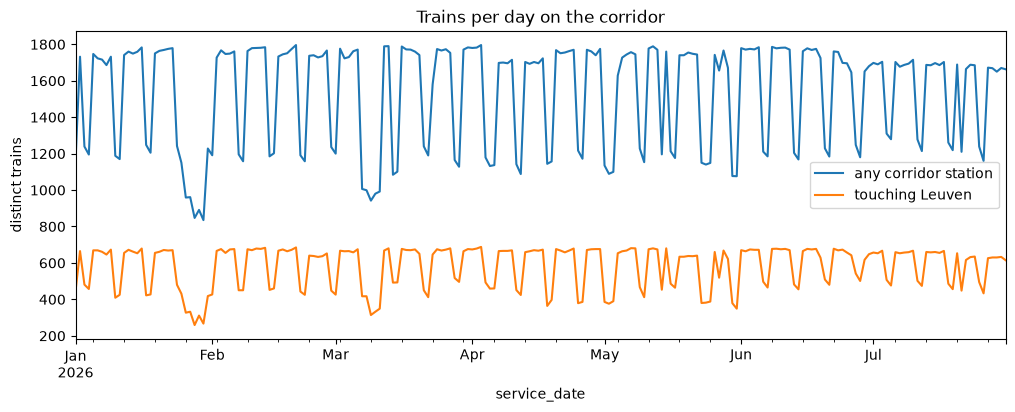

In [9]:
# a train's TRAIN_NO recurs daily, so a run is identified by (service_date, TRAIN_NO)
leuven_runs = corridor.loc[corridor["station"] == "Leuven", ["service_date", "TRAIN_NO"]].drop_duplicates()
leuven_run_keys = set(map(tuple, leuven_runs.itertuples(index=False, name=None)))
corridor["touches_leuven"] = [key in leuven_run_keys for key in zip(corridor["service_date"], corridor["TRAIN_NO"])]

trains_per_day = corridor.groupby("service_date")["TRAIN_NO"].nunique()
leuven_trains_per_day = corridor.loc[corridor["touches_leuven"]].groupby("service_date")["TRAIN_NO"].nunique()

print(f"{corridor['TRAIN_NO'].nunique()} distinct train numbers appear somewhere on the corridor")
print(f"{leuven_runs['TRAIN_NO'].nunique()} distinct train numbers actually stop at Leuven")
print("\ntrains/day touching any corridor station:")
print(trains_per_day.describe())
print("\ntrains/day touching Leuven specifically:")
print(leuven_trains_per_day.describe())

fig, ax = plt.subplots(figsize=(12, 4))
trains_per_day.plot(ax=ax, label="any corridor station")
leuven_trains_per_day.plot(ax=ax, label="touching Leuven")
ax.set_ylabel("distinct trains")
ax.set_title("Trains per day on the corridor")
ax.legend()
plt.show()

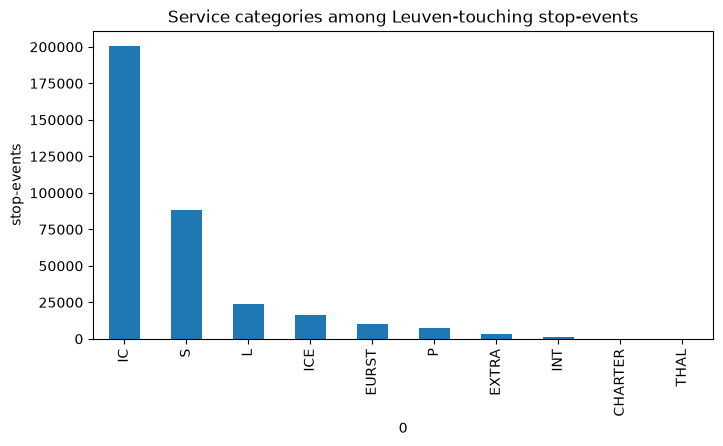

0
IC         200907
S           88153
L           24155
ICE         16072
EURST        9991
P            7157
EXTRA        3659
INT           996
CHARTER       122
THAL            5
Name: count, dtype: int64

In [10]:
service_type = corridor.loc[corridor["touches_leuven"], "RELATION"].str.extract(r"^([A-Za-z]+)")[0]
service_type.value_counts().plot(kind="bar", figsize=(8, 4), title="Service categories among Leuven-touching stop-events")
plt.ylabel("stop-events")
plt.show()
service_type.value_counts()

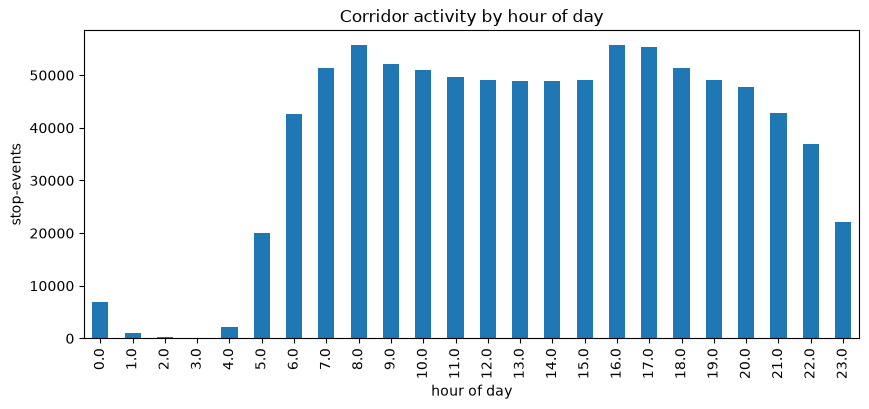

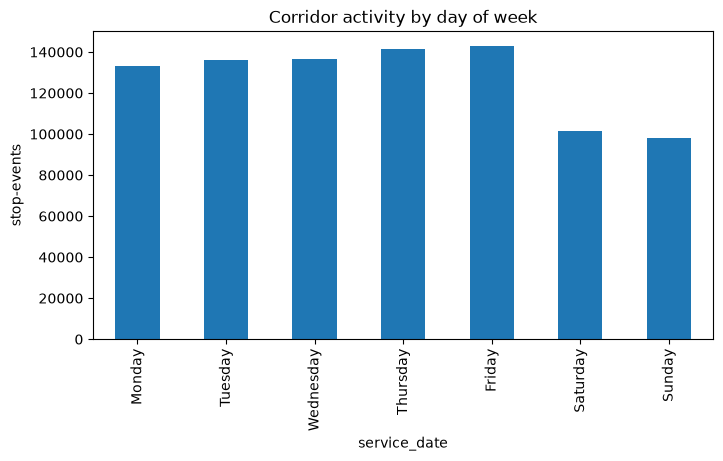

In [11]:
hour = corridor["planned_departure"].dt.hour.fillna(corridor["planned_arrival"].dt.hour)
fig, ax = plt.subplots(figsize=(10, 4))
hour.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("hour of day")
ax.set_ylabel("stop-events")
ax.set_title("Corridor activity by hour of day")
plt.show()

dow = corridor["service_date"].dt.day_name()
dow.value_counts().reindex(DOW_ORDER).plot(kind="bar", figsize=(8, 4), title="Corridor activity by day of week")
plt.ylabel("stop-events")
plt.show()

Clear morning/evening commuter peaks, and a quieter weekend: exactly what you'd expect from a commuter corridor rather than a random sample of trains.

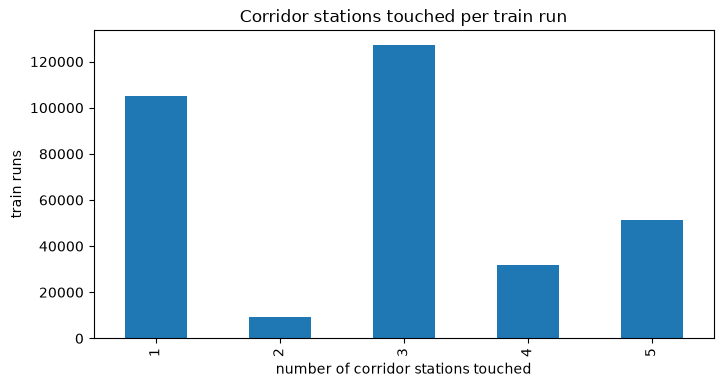

station
1    105158
2      9142
3    127184
4     31990
5     51458
Name: count, dtype: int64

In [12]:
stops_per_run = corridor.groupby(["service_date", "TRAIN_NO"])["station"].nunique()
stops_per_run.value_counts().sort_index().plot(kind="bar", figsize=(8, 4), title="Corridor stations touched per train run")
plt.xlabel("number of corridor stations touched")
plt.ylabel("train runs")
plt.show()
stops_per_run.value_counts().sort_index()

In [13]:
touches_leuven_per_run = corridor.groupby(["service_date", "TRAIN_NO"])["touches_leuven"].first()

leuven_reach = pd.crosstab(stops_per_run, touches_leuven_per_run)
leuven_reach.columns = ["doesn't reach Leuven", "reaches Leuven"]
leuven_reach.index.name = "stations touched"
leuven_reach["% reaching Leuven"] = (leuven_reach["reaches Leuven"] / leuven_reach.sum(axis=1) * 100).round(1)
leuven_reach

,doesn't reach Leuven,reaches Leuven,% reaching Leuven
stations touched,,,
1,48805,56353,53.6
2,497,8645,94.6
3,120498,6686,5.3
4,31941,49,0.2
5,0,51458,100.0


The station-count histogram above is actually a red herring for "does this run reach Leuven" -- the table above, cross-tabbed against the precise `touches_leuven` flag, shows the relationship isn't even monotonic: 2-station runs reach Leuven 95% of the time, but 3-station runs reach it only 5% of the time.

Why: two structurally different sub-routes share these six stations. The IC line runs through up to four Brussels-side stations, then either continues on to Leuven or terminates/diverts elsewhere without ever getting there (a real example from the data: `Brussels-South -> Brussels-Central -> Brussels-North`, done -- 3 stations, no Leuven). The S-line is a short hop via Schuman -> Kortenberg -> Leuven (a real example: `Kortenberg -> Leuven` -- 2 stations, reaches Leuven). Station count alone can't separate these two populations. `touches_leuven` -- not this histogram -- is the reliable way to identify genuine Leuven services.

## 🌤️ Weather Impact

In [14]:
weather = pd.read_csv(WEATHER_PATH)
weather["time"] = pd.to_datetime(weather["time"])
weather = weather.rename(columns={"time": "weather_hour", "location": "weather_location"})

corridor = corridor.merge(weather, on=["weather_hour", "weather_location"], how="left")
print(f"weather match rate: {corridor['temperature_2m'].notna().mean():.4%}")
corridor[["station", "event_time", "weather_hour", "temperature_2m", "precipitation"]].head()

weather match rate: 99.9911%


,station,event_time,weather_hour,temperature_2m,precipitation
0,Brussels-South,2026-01-01 06:22:58,2026-01-01 06:00:00,0.5,0.0
1,Brussels-Central,2026-01-01 06:25:54,2026-01-01 06:00:00,0.5,0.0
2,Brussels-North,2026-01-01 06:29:01,2026-01-01 06:00:00,0.5,0.0
3,Kortenberg,2026-01-01 06:38:15,2026-01-01 07:00:00,1.1,0.0
4,Leuven,2026-01-01 06:43:04,2026-01-01 07:00:00,1.3,0.0


In [15]:
corridor.head()

,DATDEP,CIRC_TYP,TRAIN_NO,RELATION,TRAIN_SERV,OP1_COD,THOP1_COD,PTCAR_NO,PTCAR_LG_NM_NL,LINE_NO_DEP,REAL_DATE_ARR,REAL_TIME_ARR,REAL_DATE_DEP,REAL_TIME_DEP,PLANNED_DATE_ARR,PLANNED_TIME_ARR,PLANNED_TIME_DEP,PLANNED_DATE_DEP,DELAY_ARR,DELAY_DEP,RELATION_DIRECTION,LINE_NO_ARR,source_month,service_date,planned_arrival,real_arrival,planned_departure,real_departure,delay_arr_s,delay_dep_s,delay_arr_min,delay_dep_min,station,event_time,weather_location,weather_hour,touches_leuven,temperature_2m,precipitation,rain,wind_speed_10m,wind_gusts_10m,weather_code
0,01JAN2026,1,11,ICE,SNCB/NMBS,NaN,NaN,220,BRUSSEL-ZUID,0/1,NaN,NaN,01JAN2026,6:22:58,NaN,NaN,6:23:00,01JAN2026,NaN,-1,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,NaN,202601,2026-01-01,NaT,NaT,2026-01-01 06:23:00,2026-01-01 06:22:58,NaN,-1.0,NaN,-0.016667,Brussels-South,2026-01-01 06:22:58,Brussels,2026-01-01 06:00:00,True,0.5,0.0,0.0,19.3,40.0,1.0
1,01JAN2026,1,11,ICE,SNCB/NMBS,P,P,215,BRUSSEL-CENTRAAL,0/1,01JAN2026,6:25:54,01JAN2026,6:25:54,01JAN2026,6:26:00,6:26:00,01JAN2026,-6,-6,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,0/1,202601,2026-01-01,2026-01-01 06:26:00,2026-01-01 06:25:54,2026-01-01 06:26:00,2026-01-01 06:25:54,-6.0,-6.0,-0.100000,-0.100000,Brussels-Central,2026-01-01 06:25:54,Brussels,2026-01-01 06:00:00,True,0.5,0.0,0.0,19.3,40.0,1.0
2,01JAN2026,1,11,ICE,SNCB/NMBS,=,=,221,BRUSSEL-NOORD,36N,01JAN2026,6:29:01,01JAN2026,6:31:12,01JAN2026,6:29:00,6:31:00,01JAN2026,2,12,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,0/1,202601,2026-01-01,2026-01-01 06:29:00,2026-01-01 06:29:01,2026-01-01 06:31:00,2026-01-01 06:31:12,2.0,12.0,0.033333,0.200000,Brussels-North,2026-01-01 06:29:01,Brussels,2026-01-01 06:00:00,True,0.5,0.0,0.0,19.3,40.0,1.0
3,01JAN2026,1,11,ICE,SNCB/NMBS,D,D,648,KORTENBERG,36N,01JAN2026,6:38:15,01JAN2026,6:38:15,01JAN2026,6:39:00,6:39:00,01JAN2026,-45,-45,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,36N,202601,2026-01-01,2026-01-01 06:39:00,2026-01-01 06:38:15,2026-01-01 06:39:00,2026-01-01 06:38:15,-45.0,-45.0,-0.750000,-0.750000,Kortenberg,2026-01-01 06:38:15,Brussels,2026-01-01 07:00:00,True,1.1,0.0,0.0,20.5,43.2,0.0
4,01JAN2026,1,11,ICE,SNCB/NMBS,P,P,715,LEUVEN,2,01JAN2026,6:43:04,01JAN2026,6:43:04,01JAN2026,6:45:00,6:45:00,01JAN2026,-116,-116,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,36N,202601,2026-01-01,2026-01-01 06:45:00,2026-01-01 06:43:04,2026-01-01 06:45:00,2026-01-01 06:43:04,-116.0,-116.0,-1.933333,-1.933333,Leuven,2026-01-01 06:43:04,Leuven,2026-01-01 07:00:00,True,1.3,0.0,0.0,20.3,39.2,0.0


In [16]:
# For codes, please see https://open-meteo.com/en/docs#weather_variable_documentation

WEATHER_BUCKETS = {
    0: "clear", 1: "mostly clear", 2: "cloudy", 3: "overcast",
    45: "fog", 48: "fog",
    51: "drizzle", 53: "drizzle", 55: "drizzle",
    61: "rain", 63: "rain", 65: "rain",
    71: "snow", 73: "snow", 75: "snow",
    80: "showers", 81: "showers", 82: "showers",
    95: "storm", 96: "storm", 99: "storm",
}
corridor["weather_bucket"] = corridor["weather_code"].map(WEATHER_BUCKETS)
corridor["weather_bucket"].value_counts()

weather_bucket
overcast        316815
clear           226505
drizzle         144672
mostly clear     94641
cloudy           82474
rain             14205
snow             10892
Name: count, dtype: int64

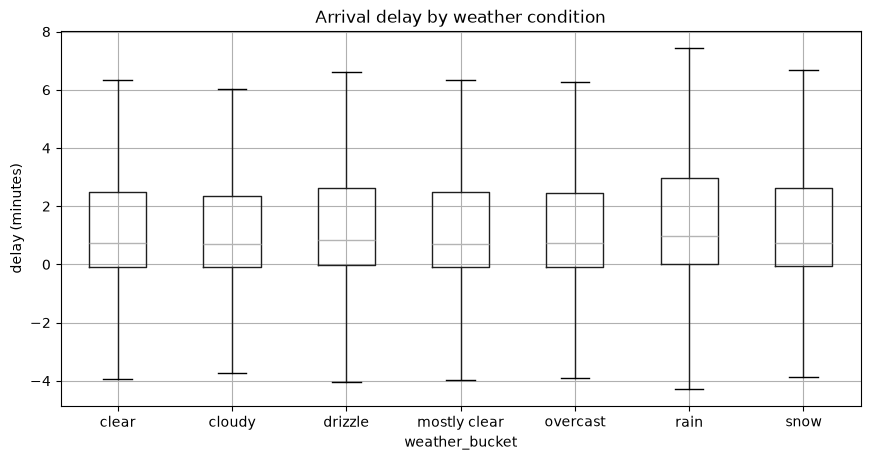

,mean,median,count
weather_bucket,,,
mostly clear,2.504518,0.716667,86471
cloudy,2.515299,0.716667,75590
clear,2.538483,0.733333,207008
overcast,2.598692,0.733333,289138
drizzle,2.638748,0.833333,132499
snow,2.743544,0.750000,9955
rain,2.792768,0.966667,12949


In [17]:
plot_data = corridor.dropna(subset=["delay_arr_min", "weather_bucket"])
order = plot_data.groupby("weather_bucket")["delay_arr_min"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 5))
plot_data.boxplot(column="delay_arr_min", by="weather_bucket", ax=ax, showfliers=False)
plt.suptitle("")
ax.set_title("Arrival delay by weather condition")
ax.set_ylabel("delay (minutes)")
plt.show()

plot_data.groupby("weather_bucket")["delay_arr_min"].agg(["mean", "median", "count"]).sort_values("mean")

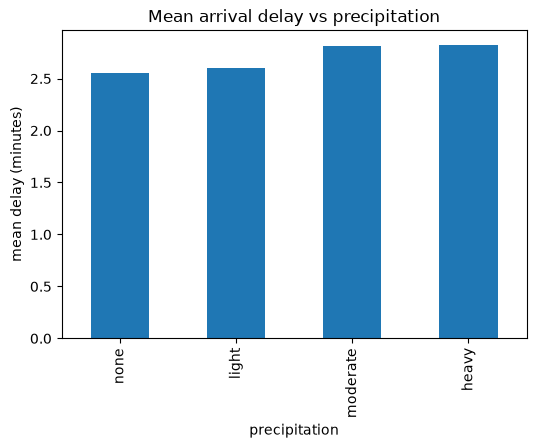

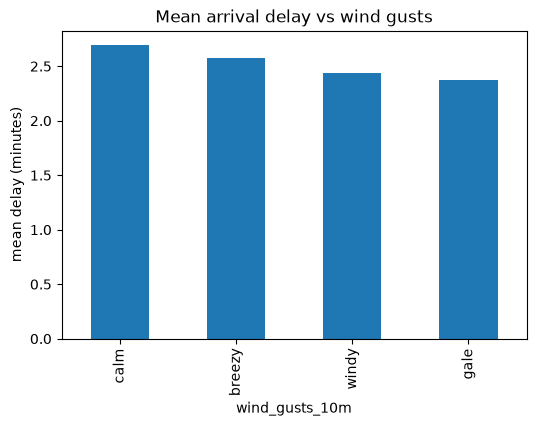

In [18]:
precip_bucket = pd.cut(corridor["precipitation"], bins=[-0.01, 0, 0.5, 2, 100], labels=["none", "light", "moderate", "heavy"])
corridor.groupby(precip_bucket)["delay_arr_min"].mean().plot(kind="bar", figsize=(6, 4), title="Mean arrival delay vs precipitation")
plt.ylabel("mean delay (minutes)")
plt.show()

wind_bucket = pd.cut(corridor["wind_gusts_10m"], bins=[0, 20, 40, 60, 200], labels=["calm", "breezy", "windy", "gale"])
corridor.groupby(wind_bucket)["delay_arr_min"].mean().plot(kind="bar", figsize=(6, 4), title="Mean arrival delay vs wind gusts")
plt.ylabel("mean delay (minutes)")
plt.show()

Rain and stronger wind gusts both nudge mean delay up, but the effect is modest next to the day-to-day operational noise. Weather looks like a real but secondary signal, not the main driver.

## ⏰ Delay Patterns & Analysis

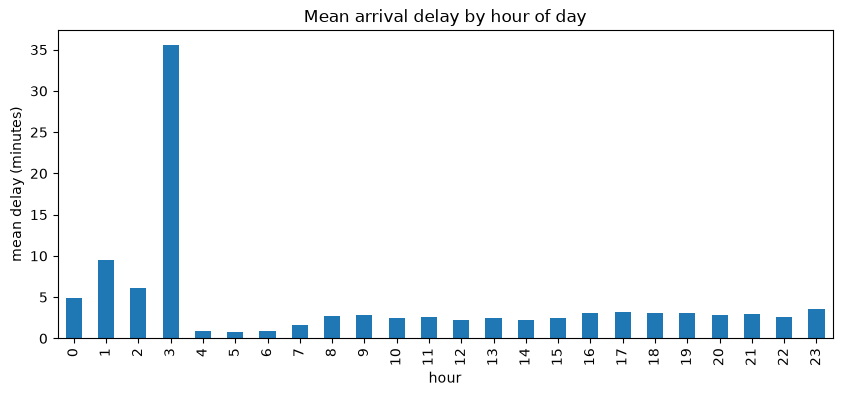

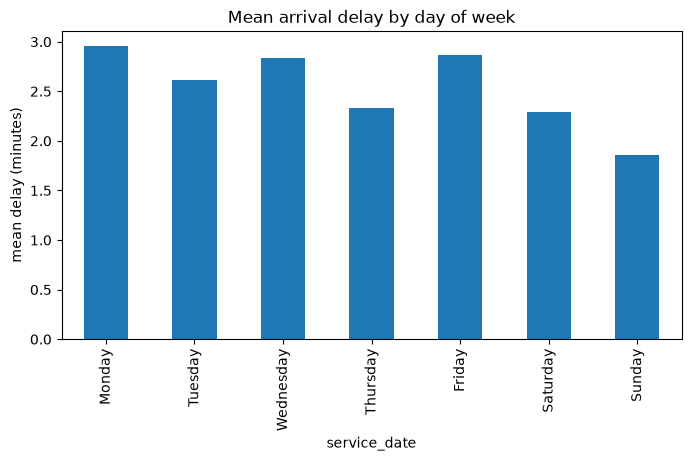

In [19]:
observed = corridor.dropna(subset=["delay_arr_min"])

by_hour = observed.groupby(observed["real_arrival"].dt.hour)["delay_arr_min"].mean()
by_hour.plot(kind="bar", figsize=(10, 4), title="Mean arrival delay by hour of day")
plt.xlabel("hour")
plt.ylabel("mean delay (minutes)")
plt.show()

by_dow = observed.groupby(observed["service_date"].dt.day_name())["delay_arr_min"].mean().reindex(DOW_ORDER)
by_dow.plot(kind="bar", figsize=(8, 4), title="Mean arrival delay by day of week")
plt.ylabel("mean delay (minutes)")
plt.show()

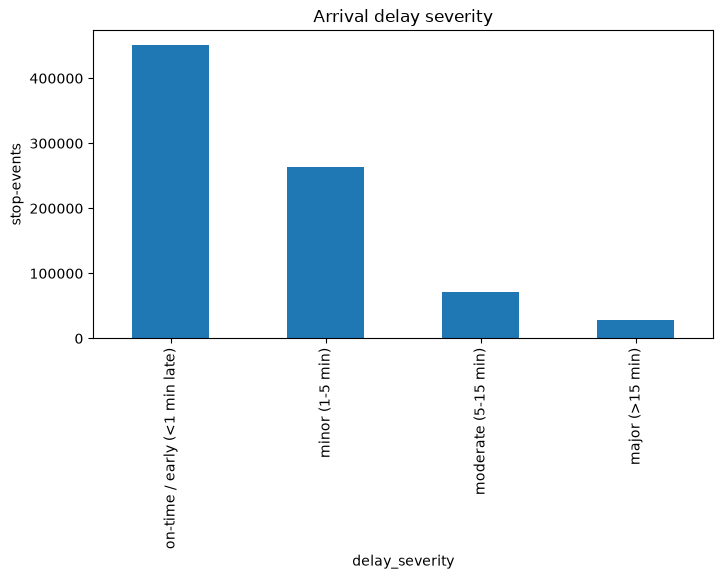

delay_severity
on-time / early (<1 min late)    55.4
minor (1-5 min)                  32.3
moderate (5-15 min)               8.8
major (>15 min)                   3.5
Name: count, dtype: float64

In [20]:
bins = [-np.inf, 59, 300, 900, np.inf]
labels = ["on-time / early (<1 min late)", "minor (1-5 min)", "moderate (5-15 min)", "major (>15 min)"]
corridor["delay_severity"] = pd.cut(corridor["delay_arr_s"], bins=bins, labels=labels)

counts = corridor["delay_severity"].value_counts().reindex(labels)
counts.plot(kind="bar", figsize=(8, 4), title="Arrival delay severity")
plt.ylabel("stop-events")
plt.show()
(counts / counts.sum() * 100).round(1)

correlation between a stop's arrival delay and the previous stop's arrival delay: 0.978


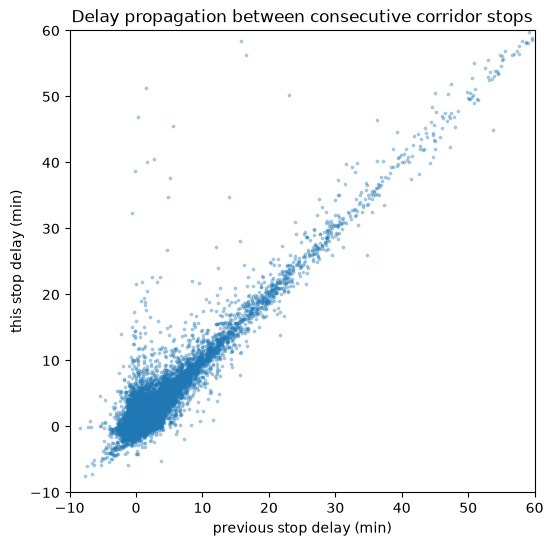

In [21]:
by_run = corridor.dropna(subset=["real_arrival", "delay_arr_min"]).sort_values(["service_date", "TRAIN_NO", "real_arrival"])
by_run["prev_delay_arr_min"] = by_run.groupby(["service_date", "TRAIN_NO"])["delay_arr_min"].shift(1)

prop = by_run.dropna(subset=["prev_delay_arr_min"])
corr = prop["delay_arr_min"].corr(prop["prev_delay_arr_min"])
print(f"correlation between a stop's arrival delay and the previous stop's arrival delay: {corr:.3f}")

sample = prop.sample(min(20000, len(prop)), random_state=0)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample["prev_delay_arr_min"], sample["delay_arr_min"], s=3, alpha=0.3)
ax.set_xlabel("previous stop delay (min)")
ax.set_ylabel("this stop delay (min)")
ax.set_title("Delay propagation between consecutive corridor stops")
ax.set_xlim(-10, 60)
ax.set_ylim(-10, 60)
plt.show()

Delay propagation is strong: a train that's late at one corridor stop is, almost one-for-one, still late at the next one. That's exactly the kind of signal a 1-hour-ahead warning model can lean on; an upstream delay right now is informative about what happens downstream shortly after.

## 📊 Data Quality & Coverage

- Is the data actually complete over time, or are there gaps/dips in coverage?
- Where are the missing values, and do they make sense?
- Are there outliers in the delay values, and can you tell what caused them?

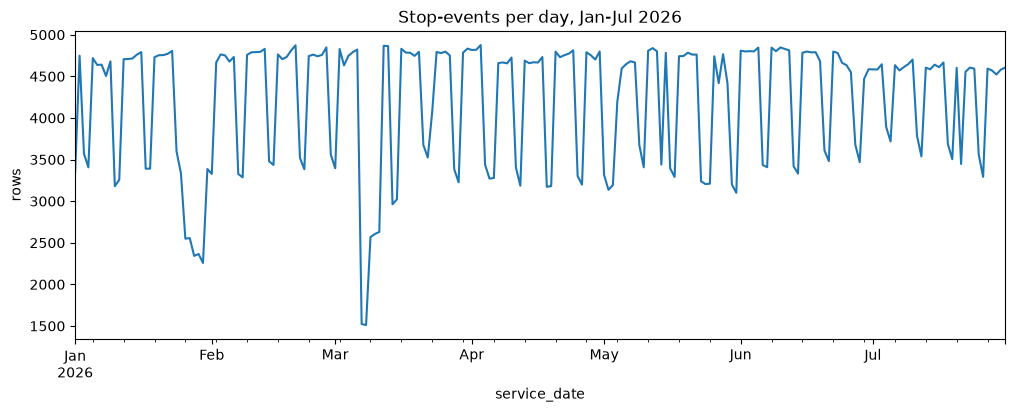

0 calendar days with zero rows out of 212

lowest-coverage days:
service_date
2026-03-08    1511
2026-03-07    1523
2026-01-30    2257
2026-01-28    2342
2026-01-29    2365
2026-01-26    2549
2026-01-27    2556
2026-03-09    2568
dtype: int64


In [22]:
daily_counts = corridor.groupby("service_date").size()
fig, ax = plt.subplots(figsize=(12, 4))
daily_counts.plot(ax=ax)
ax.set_title("Stop-events per day, Jan-Jul 2026")
ax.set_ylabel("rows")
plt.show()

full_range = pd.date_range(corridor["service_date"].min(), corridor["service_date"].max(), freq="D")
missing_days = full_range.difference(daily_counts.index)
print(f"{len(missing_days)} calendar days with zero rows out of {len(full_range)}")
print("\nlowest-coverage days:")
print(daily_counts.sort_values().head(8))

No calendar day is entirely missing, but late January and the first half of March show a visible dip; partial-day collection artifacts rather than trains simply not running. Worth knowing about before trusting any "trains per day" number too literally.

In [23]:
cols_of_interest = ["REAL_DATE_ARR", "REAL_DATE_DEP", "PLANNED_DATE_ARR", "PLANNED_DATE_DEP", "RELATION_DIRECTION"]
print(corridor[cols_of_interest].isna().sum())

first_stop_example = corridor.loc[corridor["real_arrival"].isna()].iloc[0]
print("\nexample of a train's very first stop (no arrival, only a departure):")
print(first_stop_example[["service_date", "TRAIN_NO", "station", "real_arrival", "real_departure"]])

REAL_DATE_ARR         76597
REAL_DATE_DEP         76476
PLANNED_DATE_ARR      76597
PLANNED_DATE_DEP      76476
RELATION_DIRECTION    40698
dtype: int64

example of a train's very first stop (no arrival, only a departure):
service_date      2026-01-01 00:00:00
TRAIN_NO                           11
station                Brussels-South
real_arrival                      NaT
real_departure    2026-01-01 06:22:58
Name: 0, dtype: object


In [24]:
rd_missing = corridor.loc[corridor["RELATION_DIRECTION"].isna(), "RELATION"].str.extract(r"^([A-Za-z]+)")[0]
print("RELATION_DIRECTION is missing mostly for non-passenger/irregular categories, not core IC/S services:")
print(rd_missing.value_counts())

RELATION_DIRECTION is missing mostly for non-passenger/irregular categories, not core IC/S services:
0
P          29710
EXTRA      10316
L            493
CHARTER      170
THAL           5
INT            3
TGV            1
Name: count, dtype: int64


In [25]:
key = list(zip(corridor["service_date"], corridor["TRAIN_NO"], corridor["station"]))
dup_mask = pd.Series(key).duplicated(keep=False)
print(f"{dup_mask.sum()} rows share the same (date, train number, station)")
corridor.loc[dup_mask.values, ["service_date", "TRAIN_NO", "RELATION", "station", "real_arrival", "RELATION_DIRECTION"]].sort_values(["service_date", "TRAIN_NO"]).head(6)

78 rows share the same (date, train number, station)


,service_date,TRAIN_NO,RELATION,station,real_arrival,RELATION_DIRECTION
38819,2026-01-10,2604,IC 08,Kortenberg,2026-01-10 05:02:04,IC 08: ANTWERPEN-CENTRAAL -> HASSELT
38820,2026-01-10,2604,IC 08,Kortenberg,2026-01-10 05:26:28,IC 08: ANTWERPEN-CENTRAAL -> HASSELT
38841,2026-01-10,2605,IC 08,Kortenberg,2026-01-10 06:02:37,IC 08: ANTWERPEN-CENTRAAL -> HASSELT
38842,2026-01-10,2605,IC 08,Kortenberg,2026-01-10 06:26:24,IC 08: ANTWERPEN-CENTRAAL -> HASSELT
38849,2026-01-10,2606,IC 08,Kortenberg,2026-01-10 07:07:23,IC 08: ANTWERPEN-CENTRAAL -> HASSELT
38850,2026-01-10,2606,IC 08,Kortenberg,2026-01-10 07:32:54,IC 08: ANTWERPEN-CENTRAAL -> HASSELT


(date, TRAIN_NO, station) isn't a fully unique key: the same train number occasionally gets reused later the same day for a different circulation (a different `RELATION_DIRECTION`, hours apart). Not a data error to fix here, just a quirk the next stage should build its train-run identifier around explicitly rather than assume away.

In [26]:
outlier_threshold_s = 3 * 3600
corridor["delay_arr_is_outlier"] = corridor["delay_arr_s"].abs() > outlier_threshold_s
print(f"{corridor['delay_arr_is_outlier'].sum()} rows ({corridor['delay_arr_is_outlier'].mean():.3%}) have an arrival delay beyond 3 hours in either direction")

worst = corridor.loc[corridor["delay_arr_s"].idxmin()]
print("\nmost extreme (most negative) delay:")
print(worst[["service_date", "TRAIN_NO", "RELATION", "station", "REAL_DATE_ARR", "REAL_TIME_ARR", "PLANNED_DATE_ARR", "PLANNED_TIME_ARR", "delay_arr_min"]])

183 rows (0.021%) have an arrival delay beyond 3 hours in either direction

most extreme (most negative) delay:
service_date        2026-03-26 00:00:00
TRAIN_NO                          17301
RELATION                          EXTRA
station                Brussels-Central
REAL_DATE_ARR                 26MAR2026
REAL_TIME_ARR                   8:55:24
PLANNED_DATE_ARR              28MAR2026
PLANNED_TIME_ARR                8:20:00
delay_arr_min                   -2844.6
Name: 347306, dtype: object


That -2800-minute "delay" isn't a train running two days early `PLANNED_DATE_ARR` and `REAL_DATE_ARR` are simply different calendar days (a rescheduled/rebooked service in the source feed). Same story at the other extreme (multi-day gaps producing implausible positive delays). Rather than deleting these rows outright, we flag them with `delay_arr_is_outlier` so the next stage can decide how to treat them without losing the row.

In [27]:
print(f"weather join match rate: {corridor['temperature_2m'].notna().mean():.4%}")
corridor.loc[corridor["temperature_2m"].isna(), ["event_time", "weather_hour", "weather_location"]].head()

weather join match rate: 99.9911%


,event_time,weather_hour,weather_location
885886,2026-07-31 23:39:50,2026-08-01,Brussels
885887,2026-07-31 23:44:25,2026-08-01,Brussels
886196,2026-07-31 23:58:06,2026-08-01,Brussels
886197,2026-08-01 00:05:27,2026-08-01,Brussels
886198,2026-08-01 00:10:18,2026-08-01,Brussels


The handful of unmatched rows are all late-night trains on the very last day of the collection window, rounding past the last available weather hour, a boundary effect, not a bug.

## 🗺️ Bonus (optional): Map the Corridor

Plot the six corridor stations on a map with Folium. `stops.txt` has lat/lon for every station in Belgium, under its old (French) names, e.g. Leuven is "Louvain" in that file. Match by name, not by ID.

Don't block on this one: it's a nice-to-have, not a requirement.

In [28]:
stops = pd.read_csv(STOPS_PATH)

GTFS_NAME = {
    "Leuven": "Louvain",
    "Brussels-North": "Bruxelles-Nord",
    "Brussels-Central": "Bruxelles-Central",
    "Brussels-South": "Bruxelles-Midi",
    "Brussels-Schuman": "Bruxelles-Schuman",
    "Kortenberg": "Kortenberg",
}
station_coords = (
    stops[stops["stop_name"].isin(GTFS_NAME.values()) & stops["location_type"].eq(1)]
    .drop_duplicates("stop_name")
    .set_index("stop_name")[["stop_lat", "stop_lon"]]
)
station_coords

,stop_lat,stop_lon
stop_name,,
Kortenberg,50.89307,4.543300
Bruxelles-Schuman,50.84328,4.380725
Bruxelles-Nord,50.85966,4.360850
Bruxelles-Central,50.84565,4.356804
Bruxelles-Midi,50.83571,4.336530
Louvain,50.88228,4.715868


In [29]:
import folium

route_order = ["Leuven", "Kortenberg", "Brussels-Schuman", "Brussels-North", "Brussels-Central", "Brussels-South"]
points = [tuple(station_coords.loc[GTFS_NAME[station]]) for station in route_order]

m = folium.Map(location=[50.86, 4.5], zoom_start=11)
for station, point in zip(route_order, points):
    folium.Marker(point, tooltip=station).add_to(m)
folium.PolyLine(points, color="blue", weight=3).add_to(m)
m

## Save the Cleaned Corridor Dataset

This per-stop-event table; one row per train's stop at a station, with parsed timestamps, numeric delays, a canonical station name and weather joined in is what the next stage (feature engineering) will load directly. Kept at full row-level granularity on purpose: aggregating it away now would throw away exactly what a model needs to build features from.

In [30]:
os.makedirs("../data/checkpoints", exist_ok=True)

output_cols = [
    "service_date", "TRAIN_NO", "RELATION", "TRAIN_SERV", "RELATION_DIRECTION",
    "OP1_COD", "THOP1_COD",
    "station", "PTCAR_LG_NM_NL", "PTCAR_NO", "LINE_NO_DEP", "LINE_NO_ARR",
    "planned_arrival", "real_arrival", "delay_arr_s", "delay_arr_min",
    "planned_departure", "real_departure", "delay_dep_s", "delay_dep_min",
    "delay_severity", "delay_arr_is_outlier", "touches_leuven",
    "weather_location", "weather_hour", "weather_bucket",
    "temperature_2m", "precipitation", "rain", "wind_speed_10m", "wind_gusts_10m", "weather_code",
    "source_month",
]
clean = corridor[output_cols].copy()
clean.to_parquet(CHECKPOINT_PATH, index=False)

print(clean.shape)
clean.dtypes

(890283, 33)


service_date            datetime64[us]
TRAIN_NO                           str
RELATION                           str
TRAIN_SERV                         str
RELATION_DIRECTION                 str
OP1_COD                            str
THOP1_COD                          str
station                            str
PTCAR_LG_NM_NL                     str
PTCAR_NO                           str
LINE_NO_DEP                        str
LINE_NO_ARR                        str
planned_arrival         datetime64[us]
real_arrival            datetime64[us]
delay_arr_s                    float64
delay_arr_min                  float64
planned_departure       datetime64[us]
real_departure          datetime64[us]
delay_dep_s                    float64
delay_dep_min                  float64
delay_severity                category
delay_arr_is_outlier              bool
touches_leuven                    bool
weather_location                   str
weather_hour            datetime64[us]
weather_bucket           

In [31]:
check = pd.read_parquet(CHECKPOINT_PATH)
print(check.shape)
check.head()

(890283, 33)


,service_date,TRAIN_NO,RELATION,TRAIN_SERV,RELATION_DIRECTION,OP1_COD,THOP1_COD,station,PTCAR_LG_NM_NL,PTCAR_NO,LINE_NO_DEP,LINE_NO_ARR,planned_arrival,real_arrival,delay_arr_s,delay_arr_min,planned_departure,real_departure,delay_dep_s,delay_dep_min,delay_severity,delay_arr_is_outlier,touches_leuven,weather_location,weather_hour,weather_bucket,temperature_2m,precipitation,rain,wind_speed_10m,wind_gusts_10m,weather_code,source_month
0,2026-01-01,11,ICE,SNCB/NMBS,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,NaN,NaN,Brussels-South,BRUSSEL-ZUID,220,0/1,NaN,NaT,NaT,NaN,NaN,2026-01-01 06:23:00,2026-01-01 06:22:58,-1.0,-0.016667,NaN,False,True,Brussels,2026-01-01 06:00:00,mostly clear,0.5,0.0,0.0,19.3,40.0,1.0,202601
1,2026-01-01,11,ICE,SNCB/NMBS,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,P,P,Brussels-Central,BRUSSEL-CENTRAAL,215,0/1,0/1,2026-01-01 06:26:00,2026-01-01 06:25:54,-6.0,-0.100000,2026-01-01 06:26:00,2026-01-01 06:25:54,-6.0,-0.100000,on-time / early (<1 min late),False,True,Brussels,2026-01-01 06:00:00,mostly clear,0.5,0.0,0.0,19.3,40.0,1.0,202601
2,2026-01-01,11,ICE,SNCB/NMBS,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,=,=,Brussels-North,BRUSSEL-NOORD,221,36N,0/1,2026-01-01 06:29:00,2026-01-01 06:29:01,2.0,0.033333,2026-01-01 06:31:00,2026-01-01 06:31:12,12.0,0.200000,on-time / early (<1 min late),False,True,Brussels,2026-01-01 06:00:00,mostly clear,0.5,0.0,0.0,19.3,40.0,1.0,202601
3,2026-01-01,11,ICE,SNCB/NMBS,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,D,D,Kortenberg,KORTENBERG,648,36N,36N,2026-01-01 06:39:00,2026-01-01 06:38:15,-45.0,-0.750000,2026-01-01 06:39:00,2026-01-01 06:38:15,-45.0,-0.750000,on-time / early (<1 min late),False,True,Brussels,2026-01-01 07:00:00,clear,1.1,0.0,0.0,20.5,43.2,0.0,202601
4,2026-01-01,11,ICE,SNCB/NMBS,ICE: BRUSSEL-ZUID -> FRANKFURT(MAIN) HBF,P,P,Leuven,LEUVEN,715,2,36N,2026-01-01 06:45:00,2026-01-01 06:43:04,-116.0,-1.933333,2026-01-01 06:45:00,2026-01-01 06:43:04,-116.0,-1.933333,on-time / early (<1 min late),False,True,Leuven,2026-01-01 07:00:00,clear,1.3,0.0,0.0,20.3,39.2,0.0,202601
